In [93]:
import os
import sys

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import japanize_matplotlib

project_root = os.path.dirname(os.getcwd())
sys.path.insert(0, project_root)
import src.preprocess
from src_inference1.data import ContrailsDatasetV0, ContrailsDatasetV1

RECORD_ID = "8117010104968116414"
DATA_TYPE = "validation"
T = -1  # 最終フレーム

# 元データ

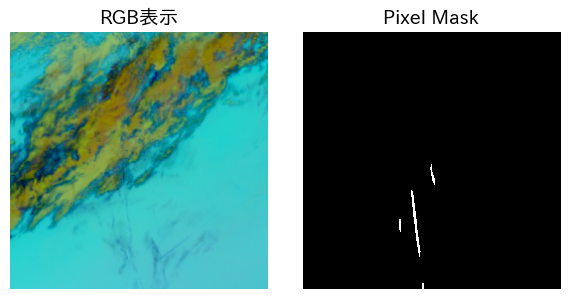

In [94]:
result = src.preprocess.process_single_record(
    base_dir=f"../data/{DATA_TYPE}", record_id=RECORD_ID,
)
fifth = result['bands'][:, :, :, 5]
pixel_mask = result['pixel_mask']

fig, ax = plt.subplots(1, 2, figsize=(6, 3))

# Band 5
ax[0].imshow(fifth)
ax[0].set_title('RGB表示', fontsize=14)
ax[0].axis('off')

# Pixel Mask
im = ax[1].imshow(pixel_mask, cmap='gray', interpolation='none')
ax[1].set_title('Pixel Mask', fontsize=14)
ax[1].axis('off')

plt.tight_layout()
plt.show()

# hdf5形式のデータセット

HDF5ファイルの構造:
キー: ['1000834164244036115', '1002653297254493116', '1002777035567823518', '1010397530434035516', '1012978360687713914', '1013721207578258217', '1024187583264624816', '1033865126042301312', '1035057907013450112', '1035874723778909718', '1046730672951575610', '1049287742871594610', '1054774014985256916', '1055808578990063312', '105832926550298819', '1064382225145937818', '1065060538005973215', '1065960904064655318', '106979780560139710', '1073716558342302517', '1073819664552417214', '1073846112869265119', '1078985191303924814', '1087514283682694318', '1087977782975734617', '1090009696130365315', '1090356748432309514', '1093513352896207014', '1093524329017073919', '1102895392990439510', '1106442435680139118', '1117561943264051312', '1119506800609937315', '1133841442642672015', '1135458921629338019', '1147688426729322418', '1150176760495756312', '1156736366420093913', '115698514338289312', '1164272724692226918', '1166190533630516915', '1171171898054346614', '117490773735672981

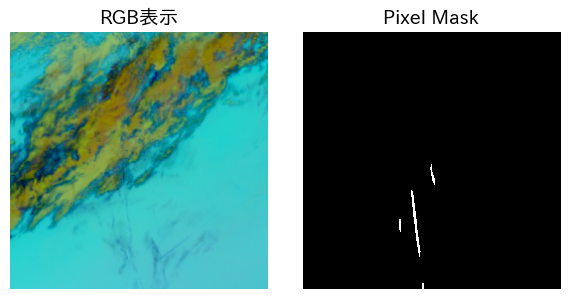

In [95]:
hdf5_path = f'../data/{DATA_TYPE}.hdf5'

# HDF5ファイルを開いて構造を確認
with h5py.File(hdf5_path, 'r') as f:
    print("HDF5ファイルの構造:")
    print(f"キー: {list(f.keys())}")
    print()
    
    # 各キーの詳細情報
    for key in f.keys():
        print(f"\n=== {key} ===")
        item = f[key]
        if isinstance(item, h5py.Dataset):
            print(f"型: Dataset")
            print(f"形状: {item.shape}")
            print(f"データ型: {item.dtype}")
            print(f"サイズ: {item.nbytes / (1024**2):.2f} MB")
        elif isinstance(item, h5py.Group):
            print(f"型: Group")
            print(f"含まれるキー: {list(item.keys())}")
            # グループ内のデータセットも確認
            for subkey in item.keys():
                subitem = item[subkey]
                if isinstance(subitem, h5py.Dataset):
                    print(f"  {subkey}: shape={subitem.shape}, dtype={subitem.dtype}")
        break

data = src.preprocess.load_from_hdf5(hdf5_path, RECORD_ID)
fifth = data['bands'][:, :, :, 5]
print(fifth.shape)

# Band 5とPixel Maskを並べて表示
fifth = data['bands'][:, :, :, 5]
pixel_mask = data['pixel_mask']

fig, ax = plt.subplots(1, 2, figsize=(6, 3))

# Band 5
ax[0].imshow(fifth)
ax[0].set_title('RGB表示', fontsize=14)
ax[0].axis('off')

# Pixel Mask
im = ax[1].imshow(pixel_mask, cmap='gray', interpolation='nearest')
ax[1].set_title('Pixel Mask', fontsize=14)
ax[1].axis('off')

plt.tight_layout()
plt.show()

# Contrails Dataset V0

入力形状: torch.Size([3, 5, 256, 256])
マスク形状: torch.Size([1, 256, 256])
入力値範囲: [0.000, 1.000]
マスク値範囲: [0.000, 1.000]


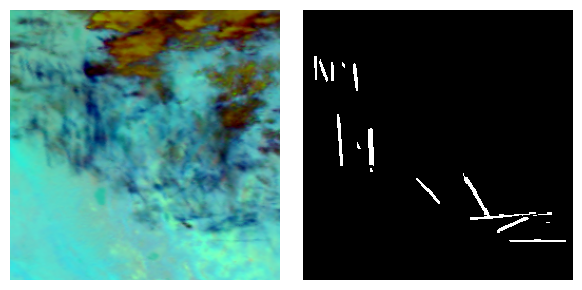

In [110]:
ds = ContrailsDatasetV0("../data", train=False, tfms=None, size=90)
img, mask = ds[0]

print(f"入力形状: {img.shape}")  # (3, 5, 256, 256)
print(f"マスク形状: {mask.shape}")  # (1, 256, 256)
print(f"入力値範囲: [{img.min():.3f}, {img.max():.3f}]")
print(f"マスク値範囲: [{mask.min():.3f}, {mask.max():.3f}]")

# 時系列フレームの可視化
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

# RGB画像 (C, H, W) -> (H, W, C)
rgb_img = img[:, T, :, :].permute(1, 2, 0).numpy()
rgb_img = np.clip(rgb_img, 0, 1)
ax[0].imshow(rgb_img)
ax[0].axis('off')

gray_mask = mask[0, :, :].numpy()
ax[1].imshow(gray_mask, cmap='gray', interpolation='nearest')
ax[1].axis('off')

plt.tight_layout()
plt.show()

# Contrails Dataset V1

入力形状: torch.Size([3, 5, 256, 256])
マスク形状: torch.Size([1, 256, 256])
入力値範囲: [0.000, 0.792]
マスク値範囲: [0.000, 0.000]


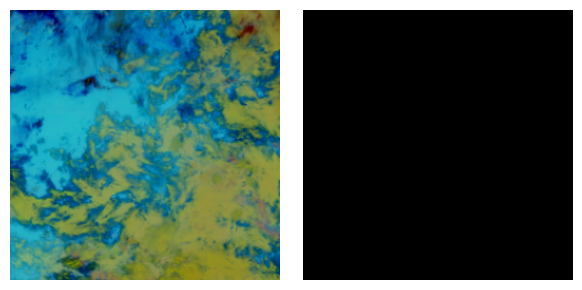

入力形状: torch.Size([3, 5, 256, 256])
マスク形状: torch.Size([1, 256, 256])
入力値範囲: [0.000, 0.792]
マスク値範囲: [0.000, 0.000]


In [112]:
import importlib
importlib.reload(src.preprocess)

ds = ContrailsDatasetV1("../data", train=False, tfms=None, size=10)
img, mask = ds[0]

print(f"入力形状: {img.shape}")  # (3, 5, 256, 256)
print(f"マスク形状: {mask.shape}")  # (1, 256, 256)
print(f"入力値範囲: [{img.min():.3f}, {img.max():.3f}]")
print(f"マスク値範囲: [{mask.min():.3f}, {mask.max():.3f}]")

# 時系列フレームの可視化
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

# RGB画像 (C, H, W) -> (H, W, C)
rgb_img = img[:, T, :, :].permute(1, 2, 0).numpy()
rgb_img = np.clip(rgb_img, 0, 1)
ax[0].imshow(rgb_img)
ax[0].axis('off')

gray_mask = mask[0, :, :].numpy()
ax[1].imshow(gray_mask, cmap='gray', interpolation='nearest')
ax[1].axis('off')

plt.tight_layout()
plt.show()
ds = ContrailsDatasetV1("../data", train=False, tfms=None, size=1)
img, mask = ds[0]

print(f"入力形状: {img.shape}")  # (3, 5, 256, 256)
print(f"マスク形状: {mask.shape}")  # (1, 256, 256)
print(f"入力値範囲: [{img.min():.3f}, {img.max():.3f}]")
print(f"マスク値範囲: [{mask.min():.3f}, {mask.max():.3f}]")